In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780998894.165824 1509292 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780998894.209300 1509292 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780998895.591720 1509292 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780998896.925404 1509292 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

In [4]:
df_train.head(3)

,tempo,delta,idade,horas_semanais,qtd_dias_afastamento,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,14.700000,0,-1.283593,0.39963,-0.15985,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,7.300000,1,-0.582427,0.39963,-0.15985,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,50.299999,0,-0.757718,0.39963,-0.15985,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


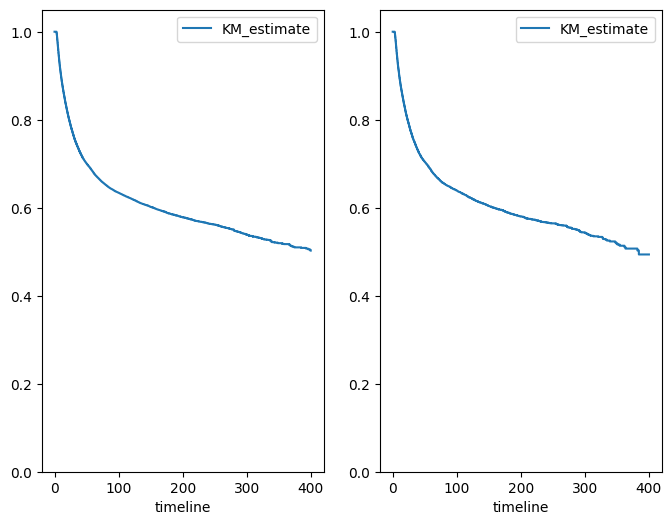

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [6]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Exponential Model

### Without covariates

In [7]:
def build_exponential_model():
    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    # parameters = {
    #     "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    # }

    parameters = {
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, y, delta = data
        
        beta = model.get_variable("beta", nn_output)
        log_beta = tf.math.log( beta )

        log_hazard = log_beta
        log_S = - y / beta

        loglik_terms = -(delta * log_beta) + log_S
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    return parameters, loglikelihood_loss, None, None, None

In [8]:
with tf.device("/CPU:0"):
    exponential_parameters, exponential_loss, exponential_neural_network, exponential_call, exponential_call_nolast = \
    build_exponential_model( )
    seed = 10
    exponential_model = thf.ModelNN(exponential_parameters, exponential_loss,
                                    exponential_neural_network, exponential_call,
                                    exponential_call_nolast, input_dim = (1,), seed = seed)
    exponential_model.train_model(epochs = 5000, x = None, data = data_train, n_train = n_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2,
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 10, 
                                  early_stopping_warmup = 10,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 10,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1561 / 5000 ]  | Loss:  39469.4141 | Best Loss:  39469.4141 | Speed:  327  epoch/s    | Elapsed Time:  4.76883411  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 7.613 seconds.


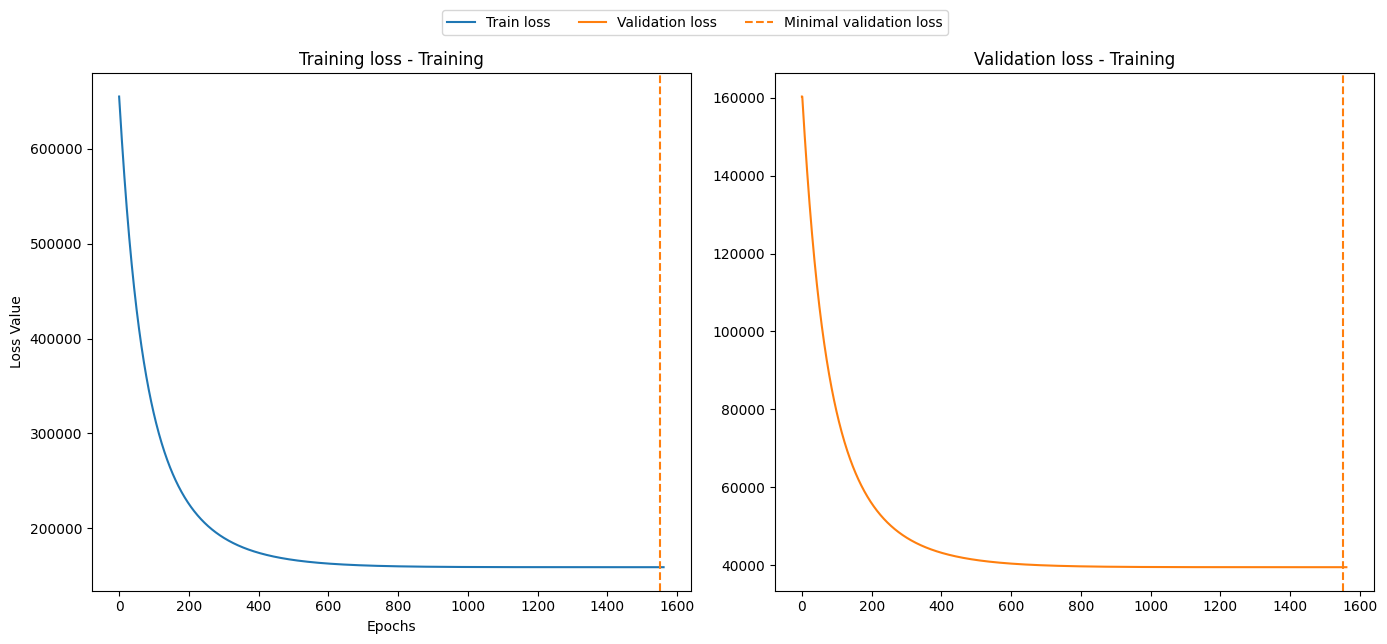

In [9]:
utils.plot_model_convergence( exponential_model )

In [10]:
beta = exponential_model.predict("beta")
print("beta:", beta)

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_train = np.exp( -ts_grid / beta )
S_ts_test = np.exp( -ts_grid / beta )

S_train = np.exp( - y_train / beta )
S_test = np.exp( - y_test / beta )
H_train = -np.log( S_train )
H_test = -np.log( S_test )

beta: [15.443197]


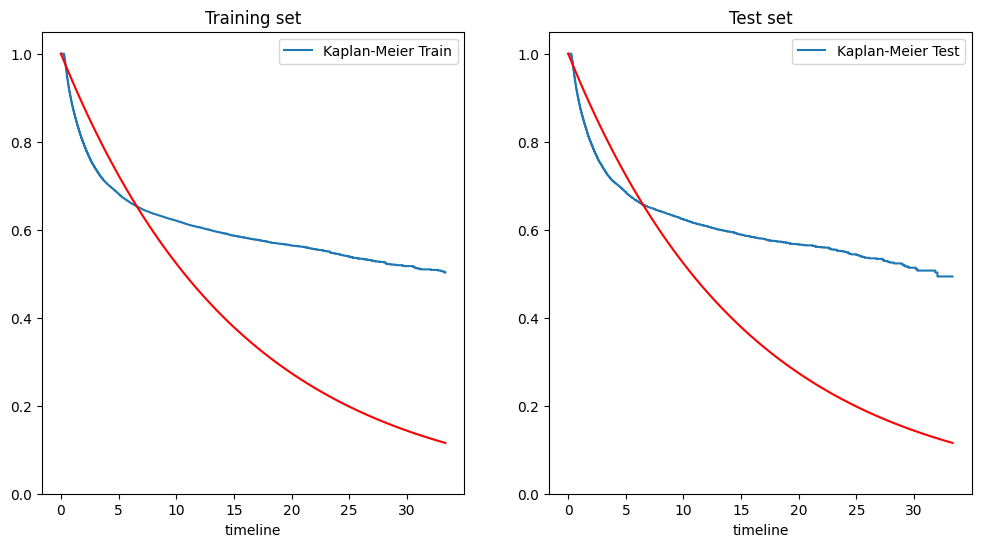

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With all covariates

In [12]:
def build_exponential_model_full( ):
    def softplus_inv(u):
        return tf.math.log(tf.math.exp(u) - 1)
    
    # parameters = {
    #     "beta": {"link": tf.math.softplus, "link_inv": softplus_inv, "par_type": "nn", "shape": 1, "init": exponential_model.predict("beta"), "warmup_time": 0},
    # }

    parameters = {
        "beta": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": exponential_model.predict("beta"), "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, y, delta = data
        
        beta = model.get_variable("beta", nn_output)
        log_beta = tf.math.log( beta )

        log_hazard = log_beta
        log_S = - y / beta

        loglik_terms = -(delta * log_beta) + log_S
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)
        
        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 1,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_beta_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [13]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [14]:
with tf.device("/GPU:0"):
    exponential_parameters, exponential_loss, exponential_neural_network, exponential_call, exponential_call_nolast = \
    build_exponential_model_full( )
    seed = 10
    exponential_model_full = thf.ModelNN(exponential_parameters, exponential_loss,
                                         exponential_neural_network, exponential_call,
                                         exponential_call_nolast, input_dim = (X_train.shape[1],), seed = seed)
    exponential_model_full.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    exponential_model_full.train_model(epochs = 5000, x = X_train, data = data_train,
                                       shuffle = True,
                                       get_covariances = True,
                                       validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                       force_training_validation = False,
                                       optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                       optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                       fine_tune_nn_lr = 0.001, fine_tune_independent_lr = 0.001,
                                       early_stopping = True, early_stopping_patience = 10, 
                                       early_stopping_warmup = 10,
                                       reduce_lr = True, reduce_lr_warmup = 0,
                                       reduce_lr_factor = 0.5, reduce_lr_min_delta = 2, reduce_lr_patience = 5,
                                       reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                       fine_tune = True,
                                       finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                       finetune_early_stopping_warmup = 10,
                                       finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                       finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1, finetune_reduce_lr_patience = 5,
                                       finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                       deterministic = True,
                                       verbose = True, print_freq = 1,
                                       train_batch_size = None, val_batch_size = None,
                                       buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 299 / 5000 ]  | Loss:  32719.0723 | Best Loss:  32720.543 | Speed:  26  epoch/s    | Elapsed Time:  11.1749325  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 20 / 5000 ]  | Loss:  130600.594 | Best Loss:  130600.773 | Speed:  50  epoch/s    | Elapsed Time:  0.398417711  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.657 seconds.


I0000 00:00:1780579242.536235 1468564 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5913966026b0


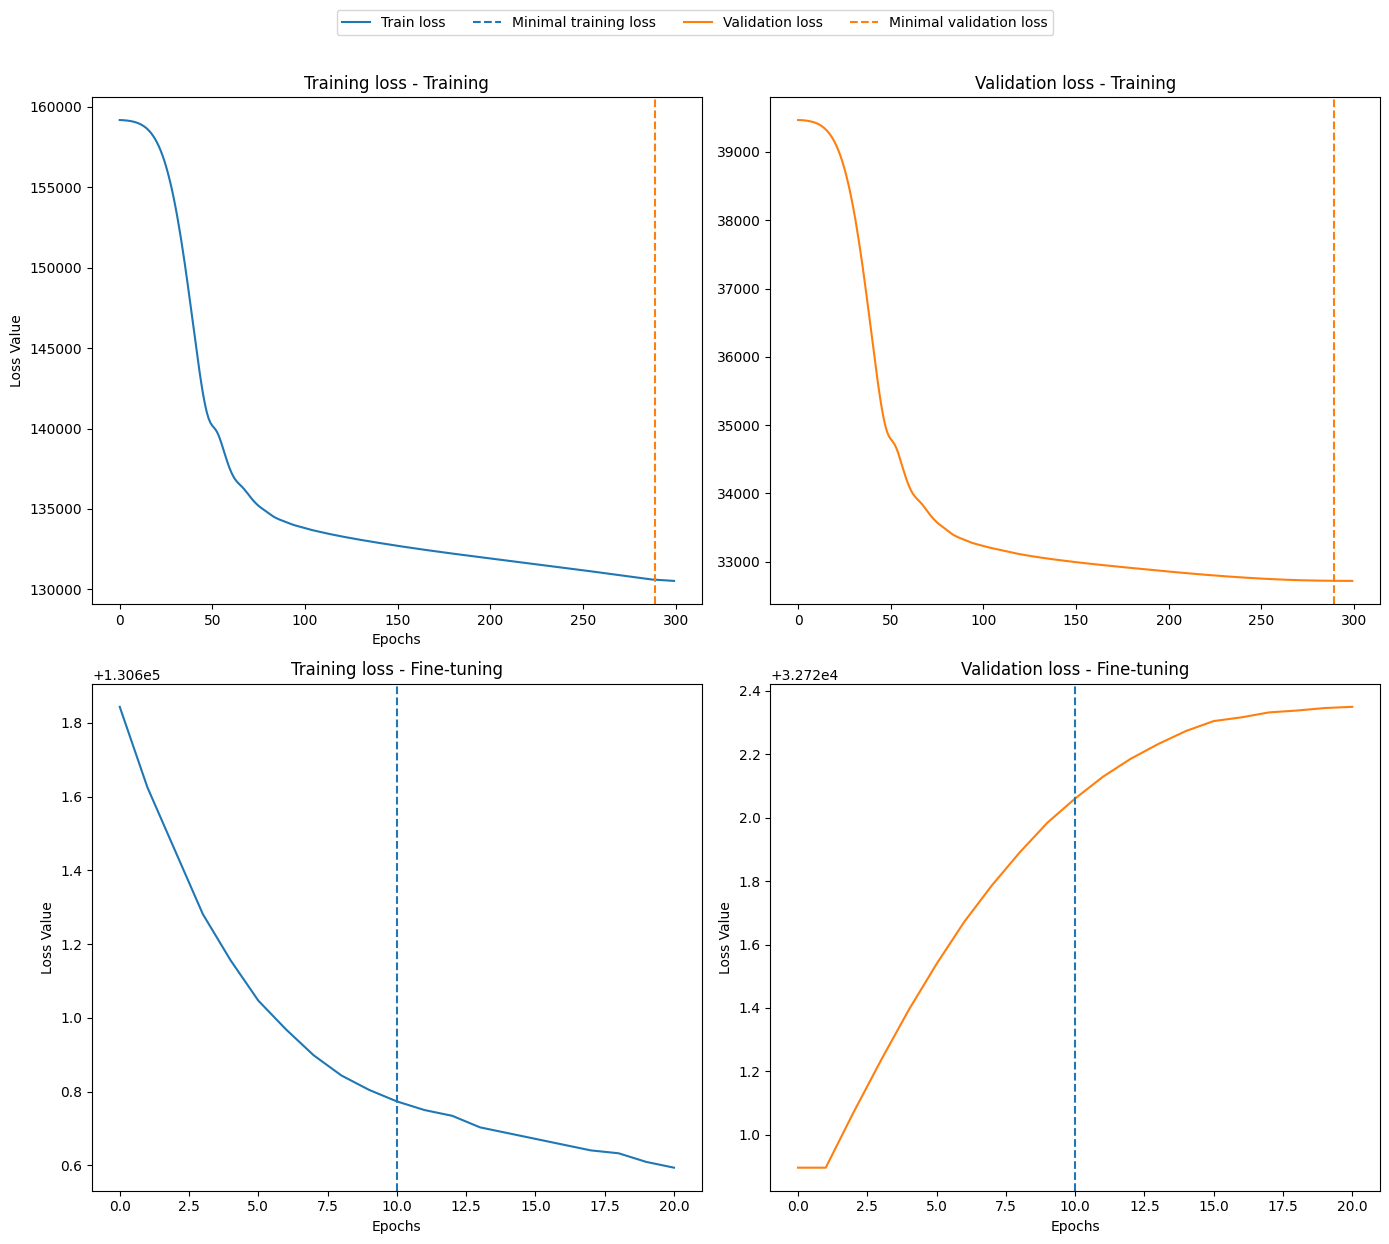

In [15]:
utils.plot_model_convergence( exponential_model_full )

In [16]:
beta_train = exponential_model_full.predict(X_train)["beta"].numpy().flatten()
beta_test = exponential_model_full.predict(X_test)["beta"].numpy().flatten()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_train_full = np.exp( -ts_grid / beta_train )
S_ts_test_full = np.exp( -ts_grid / beta_test )

S_train_full = np.exp( - y_train / beta_train )
S_test_full = np.exp( - y_test / beta_test )
H_train_full = -np.log( S_train )
H_test_full = -np.log( S_test )

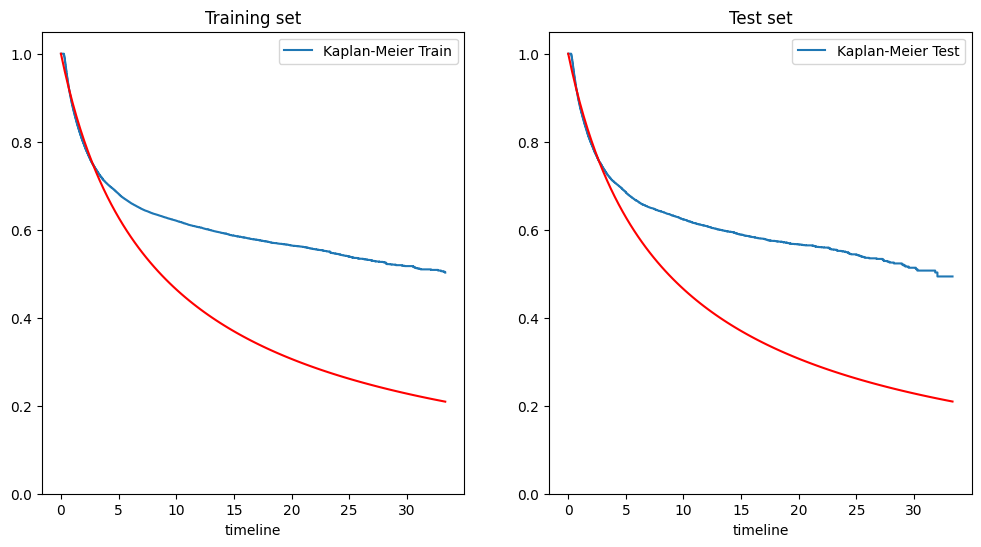

In [17]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
# n_max = 500
n_max = S_ts_train_full.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_full.shape[1]), size = np.min([n_max, S_ts_train_full.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_full.shape[1]), size = np.min([n_max, S_ts_test_full.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_full[:, train_idx], S_ts_test_full[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

### With mixed covariates

In [12]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
X_train_nn = X_train.iloc[:, neuralnet_columns]

z_test = X_test.iloc[:, linear_columns]
X_test_nn = X_test.iloc[:, neuralnet_columns]

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [21]:
def build_exponential_model_linear_effects( ridge_penalty = 1e-4, lasso_penalty = 1e-4 ):        
    parameters = {
        "beta_beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": z_train.shape[1], "init": 0.0, "warmup_time": 0},
        "beta_nn": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": exponential_model.predict("beta"), "warmup_time": 0},
    }

    def loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, z_beta, y, delta = data
        
        beta_beta = model.get_variable("beta_beta")[:,None]
        beta_nn = model.get_variable("beta_nn", nn_output)

        # beta = tf.math.softplus( tf.matmul(z_beta, beta_beta) + beta_nn )
        beta = tf.math.exp( tf.matmul(z_beta, beta_beta) + beta_nn )
        log_beta = tf.math.log( beta )
        log_S = - y / beta

        loglik_terms = -(delta * log_beta) + log_S
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    def neural_network(model, seed = None):
        initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        
        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 1,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_beta_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [22]:
with tf.device("/GPU:0"):
    exponential_parameters, exponential_loss, exponential_neural_network, exponential_call, exponential_call_nolast = \
    build_exponential_model_linear_effects( )
    seed = 10
    exponential_model_linear = thf.ModelNN(exponential_parameters, exponential_loss,
                                           exponential_neural_network, exponential_call,
                                           exponential_call_nolast, input_dim = (X_train_nn.shape[1],), seed = seed)
    exponential_model_linear.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exponential_model_linear.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                         shuffle = True,
                                         get_covariances = True,
                                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                         force_training_validation = False,
                                         optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                         optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                         fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                         early_stopping = True, early_stopping_patience = 10, 
                                         early_stopping_warmup = 10,
                                         reduce_lr = True, reduce_lr_warmup = 0,
                                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 2, reduce_lr_patience = 5,
                                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                         fine_tune = True, finetune_epochs = 5000,
                                         finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                         finetune_early_stopping_warmup = 10,
                                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1, finetune_reduce_lr_patience = 5,
                                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                         deterministic = True,
                                         verbose = True, print_freq = 1,
                                         train_batch_size = None, val_batch_size = None,
                                         buffer_size = None, gradient_accumulation_steps = None)

    exponential_model_linear.save_model("exponential_linear")

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1113 / 5000 ]  | Loss:  33235.5117 | Best Loss:  33237.0078 | Speed:  16  epoch/s    | Elapsed Time:  68.6809082  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 150 / 5000 ]  | Loss:  131957.062 | Best Loss:  131957.766 | Speed:  24  epoch/s    | Elapsed Time:  6.22930717  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 78.397 seconds.
Model successfully saved to exponential_linear.weights.h5 and exponential_linear_meta.pkl


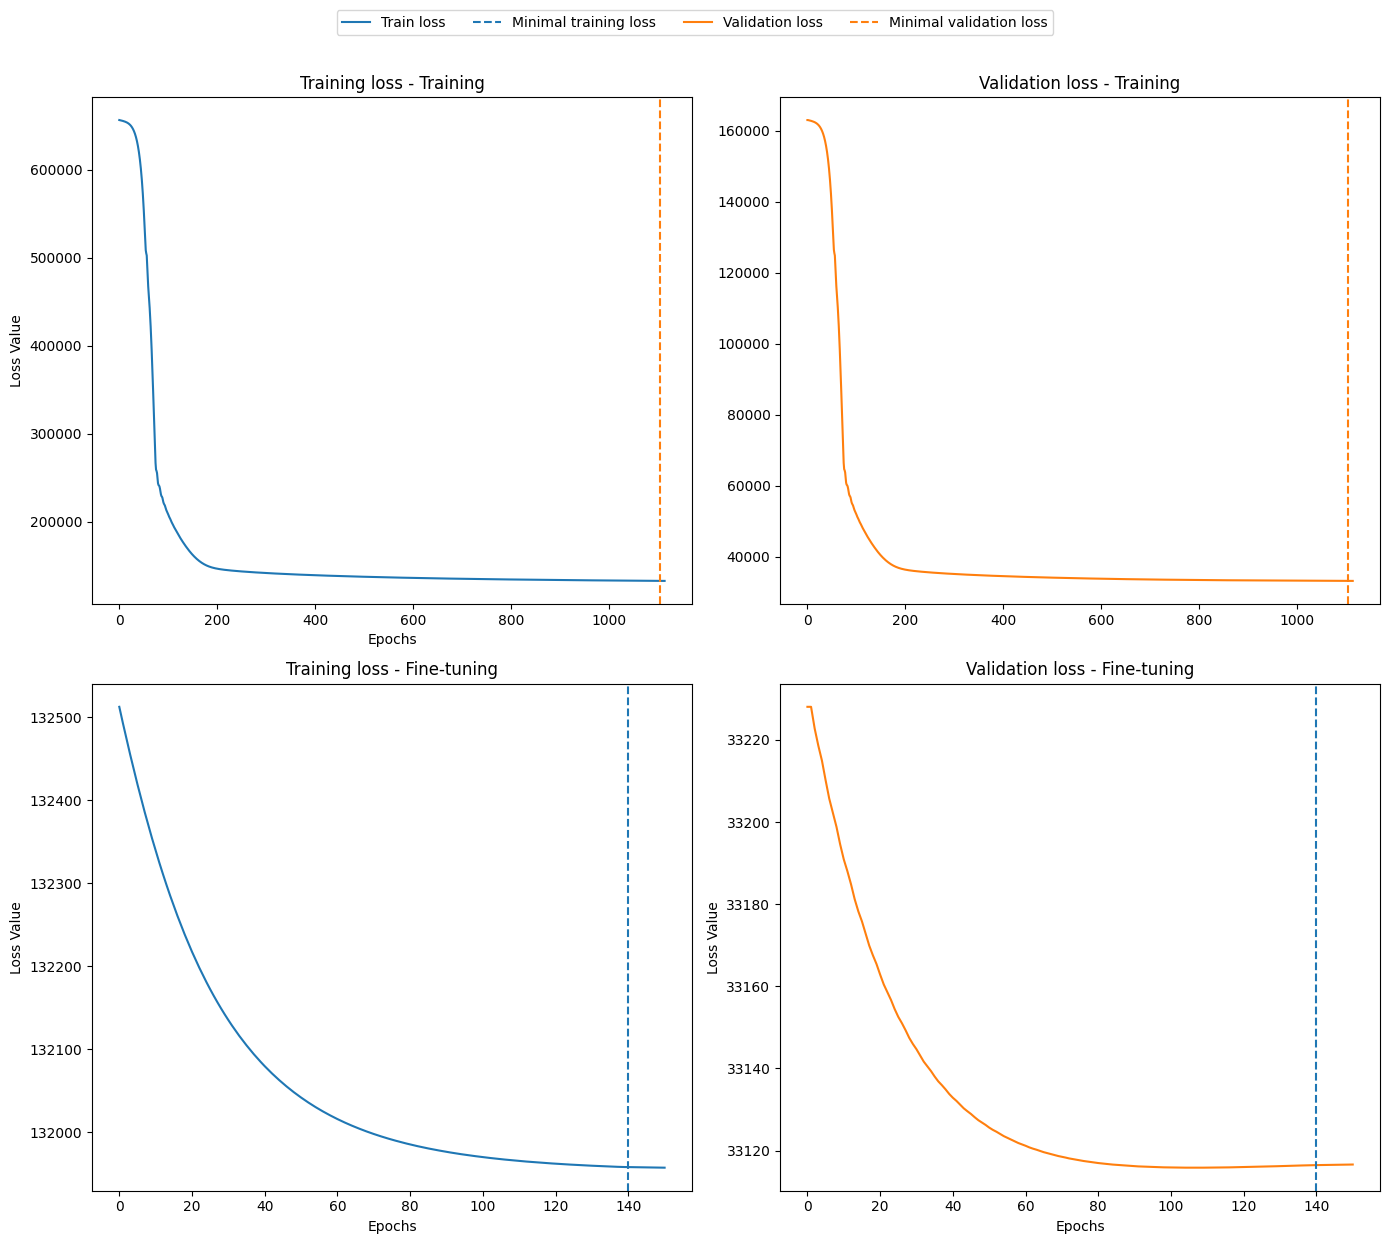

In [23]:
utils.plot_model_convergence( exponential_model_linear )

In [24]:
beta_beta_train = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_beta_test = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_nn_train = exponential_model_linear.predict(X_train_nn)["beta_nn"].numpy().flatten()
beta_nn_test = exponential_model_linear.predict(X_test_nn)["beta_nn"].numpy().flatten()
# beta_train = tf.math.softplus( beta_nn_train + np.dot(z_train, beta_beta_train).flatten() ).numpy()
# beta_test = tf.math.softplus( beta_nn_test + np.dot(z_test, beta_beta_test).flatten() ).numpy()
beta_train = tf.math.exp( beta_nn_train + np.dot(z_train, beta_beta_train).flatten() ).numpy()
beta_test = tf.math.exp( beta_nn_test + np.dot(z_test, beta_beta_test).flatten() ).numpy()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_train_linear = np.exp( - ts_grid / beta_train )
S_ts_test_linear = np.exp( - ts_grid / beta_test )

S_train_linear = np.exp( -y_train / beta_train )
S_test_linear = np.exp( -y_test / beta_test)
H_train_linear = -np.log(S_train_linear)
H_test_linear = -np.log(S_test_linear)

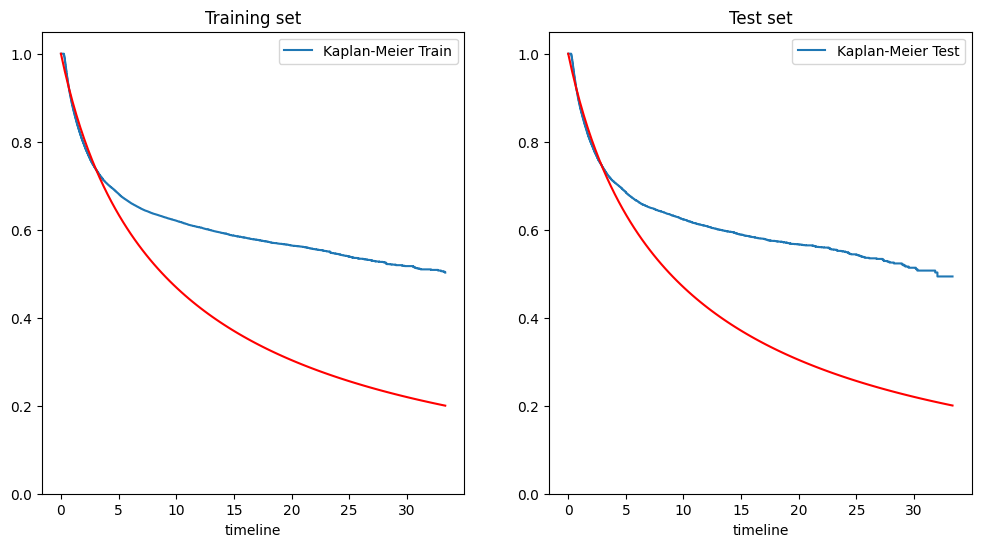

In [25]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
 
# n_max = 2000
n_max = S_ts_train_linear.shape[1]
train_idx = np.random.choice( np.arange(S_ts_train_linear.shape[1]), size = np.min([n_max, S_ts_train_linear.shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(S_ts_test_linear.shape[1]), size = np.min([n_max, S_ts_test_linear.shape[1]]), replace = False )

utils.average_kaplan_meier(ts_grid,
                           S_ts_train_linear[:, train_idx], S_ts_test_linear[:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [26]:
beta_summary = exponential_model_linear.summary()
beta_summary

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,index,beta_beta[0],beta_beta[0]_se,beta_beta[0]_lower,beta_beta[0]_upper,beta_beta[1],beta_beta[1]_se,beta_beta[1]_lower,beta_beta[1]_upper,beta_beta[2],...,beta_beta[7]_lower,beta_beta[7]_upper,beta_beta[8],beta_beta[8]_se,beta_beta[8]_lower,beta_beta[8]_upper,beta_beta[9],beta_beta[9]_se,beta_beta[9]_lower,beta_beta[9]_upper
0,1,0.546643,0.005335,0.536186,0.5571,-0.011584,0.010262,-0.031696,0.008529,-0.127525,...,0.850569,0.959152,-0.960984,0.011252,-0.983038,-0.93893,1.18372,0.03465,1.115808,1.251633


In [28]:
beta_summary = exponential_model_linear.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta_beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.546643,0.005335,102.460400,0.000000e+00,(0.5362 ; 0.5571)
sexo_feminino,-0.011584,0.010262,-1.128827,2.589707e-01,(-0.0317 ; 0.0085)
raca_amarela,-0.127525,0.045469,-2.804646,5.037194e-03,(-0.2166 ; -0.0384)
raca_indigena,-0.107635,0.091137,-1.181028,2.375914e-01,(-0.2863 ; 0.071)
raca_parda,-0.078112,0.010867,-7.187946,6.576961e-13,(-0.0994 ; -0.0568)
raca_preta,-0.094989,0.018339,-5.179687,2.222586e-07,(-0.1309 ; -0.059)
faixa_remuneracao_media_2 a 4 SM,0.634446,0.015512,40.901399,0.000000e+00,(0.604 ; 0.6648)
faixa_remuneracao_media_4 a 7 SM,0.904860,0.027700,32.666225,0.000000e+00,(0.8506 ; 0.9592)
faixa_remuneracao_media_até 1 SM,-0.960984,0.011252,-85.403138,0.000000e+00,(-0.983 ; -0.9389)
faixa_remuneracao_media_mais de 7 SM,1.183720,0.034650,34.162084,0.000000e+00,(1.1158 ; 1.2516)


Com a interpretação dos betas acima, o modelo nos informa que funcionários que ganham até 1SM tem um fator de escala consideravelmente menor. Isso indica que o tempo de vida médio desses funcionários é inferior ao tempo de vida médio de um trabalhador que ganha entre 1 e 2SM. Para conferir essa estatística, façamos um breve gráfico de comparação entre as curvas de sobrevivência observadas e preditas.

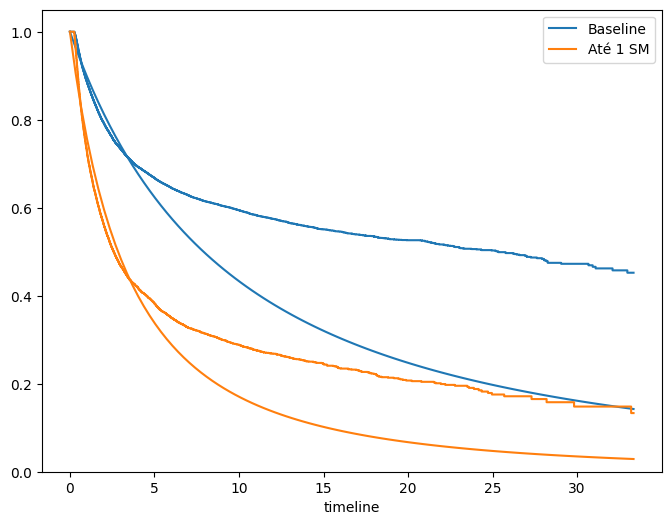

In [27]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Baseline
df_baseline = df_train.loc[ (df_train.iloc[:, [10,11,12,13]] == 0).all(axis = 1), : ]
X_baseline = df_baseline.iloc[:, 2:]
z_baseline_linear = X_baseline.iloc[:, linear_columns]
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]

beta_beta_baseline = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_nn_baseline = exponential_model_linear.predict(X_baseline_nn)["beta_nn"].numpy().flatten()

# beta_baseline = tf.math.softplus( beta_nn_baseline + np.dot(z_baseline_linear, beta_beta_baseline).flatten() ).numpy()
beta_baseline = tf.math.exp( beta_nn_baseline + np.dot(z_baseline_linear, beta_beta_baseline).flatten() ).numpy()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_baseline = np.exp( - ts_grid / beta_baseline )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(ts_grid.flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

df_ate1sm = df_train.loc[ df_train["faixa_remuneracao_media_até 1 SM"] == 1, : ]
X_ate1sm = df_ate1sm.iloc[:, 2:]
z_ate1sm_linear = X_ate1sm.iloc[:, linear_columns]
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

beta_beta_ate1sm = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_nn_ate1sm = exponential_model_linear.predict(X_ate1sm_nn)["beta_nn"].numpy().flatten()

# beta_ate1sm = tf.math.softplus( beta_nn_ate1sm + np.dot(z_ate1sm_linear, beta_beta_ate1sm).flatten() ).numpy()
beta_ate1sm = tf.math.exp( beta_nn_ate1sm + np.dot(z_ate1sm_linear, beta_beta_ate1sm).flatten() ).numpy()

S_ts_ate1sm = np.exp( - ts_grid / beta_ate1sm )

ax.plot(ts_grid.flatten(), np.mean( S_ts_ate1sm, axis = 1 ), color = colors[1])

km = lifelines.KaplanMeierFitter()
km.fit(df_baseline["tempo"] / 12, df_baseline["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = colors[0])
ax.set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_ate1sm["tempo"] / 12, df_ate1sm["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = colors[1])
ax.set_ylim(0,1.05)

plt.show()

Embora o modelo Exponencial não seja capaz de capturar o padrão inerente às curvas de Kaplan-Meier, vemos que existe uma clara diferença entre os grupos. De fato, o modelo acompanha ambas as curvas da melhor forma possível, dentro de sua família (Exponencial), justificando o coeficiente observado na média.

Façamos mais uma análise, agora com o fato contra-intuitivo de que foi identificado, com significância estatística, que as mulheres tem um tempo médio até a demissão inferior aos homens, sugerido pelo fato de seu fator de escala médio ser superior ao dos homens brancos que ganham entre 1SM e 2SM.

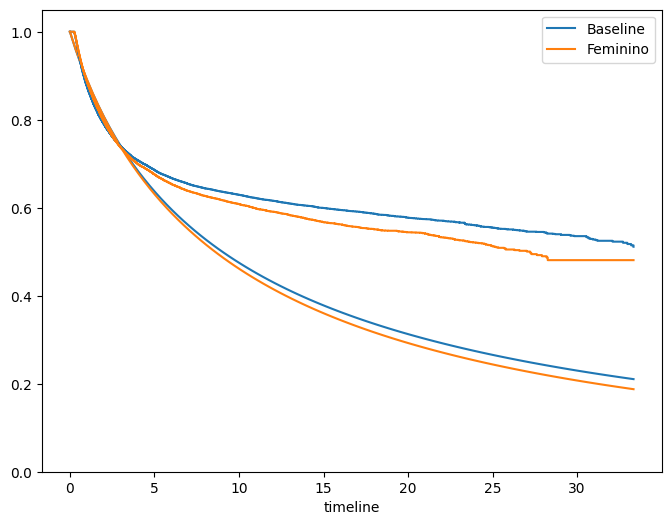

In [28]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Baseline
df_baseline = df_train.loc[ df_train["sexo_feminino"] == 0, : ]
X_baseline = df_baseline.iloc[:, 2:]
z_baseline_linear = X_baseline.iloc[:, linear_columns]
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]

beta_beta_baseline = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_nn_baseline = exponential_model_linear.predict(X_baseline_nn)["beta_nn"].numpy().flatten()

# beta_baseline = tf.math.softplus( beta_nn_baseline + np.dot(z_baseline_linear, beta_beta_baseline).flatten() ).numpy()
beta_baseline = tf.math.exp( beta_nn_baseline + np.dot(z_baseline_linear, beta_beta_baseline).flatten() ).numpy()

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), 100)[:,None]
S_ts_baseline = np.exp( - ts_grid / beta_baseline )

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(ts_grid.flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

df_feminino = df_train.loc[ df_train["sexo_feminino"] == 1, : ]
X_feminino = df_feminino.iloc[:, 2:]
z_feminino_linear = X_feminino.iloc[:, linear_columns]
X_feminino_nn = X_feminino.iloc[:, neuralnet_columns]

beta_beta_feminino = exponential_model_linear.predict( "beta_beta" )[:,None]
beta_nn_feminino = exponential_model_linear.predict(X_feminino_nn)["beta_nn"].numpy().flatten()

# beta_feminino = tf.math.softplus( beta_nn_feminino + np.dot(z_feminino_linear, beta_beta_feminino).flatten() ).numpy()
beta_feminino = tf.math.exp( beta_nn_feminino + np.dot(z_feminino_linear, beta_beta_feminino).flatten() ).numpy()

S_ts_feminino = np.exp( - ts_grid / beta_feminino )

ax.plot(ts_grid.flatten(), np.mean( S_ts_feminino, axis = 1 ), color = colors[1])

km = lifelines.KaplanMeierFitter()
km.fit(df_baseline["tempo"] / 12, df_baseline["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = colors[0])
ax.set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_feminino["tempo"] / 12, df_feminino["delta"])
km.plot(ax = ax, ci_show = False, show_censors = False, label = "Feminino", color = colors[1])
ax.set_ylim(0,1.05)

plt.show()

Vemos que a curva referente ao tempo até a demissão do sexo feminino é levemente inferior que a do sexo masculino. De fato, se analisarmos ambas as curvas de Kaplan-Meier nos tempos inferiores, veremos que a curva feminina é levemente superior, mesmo que quase imperceptível.

# Model evaluation

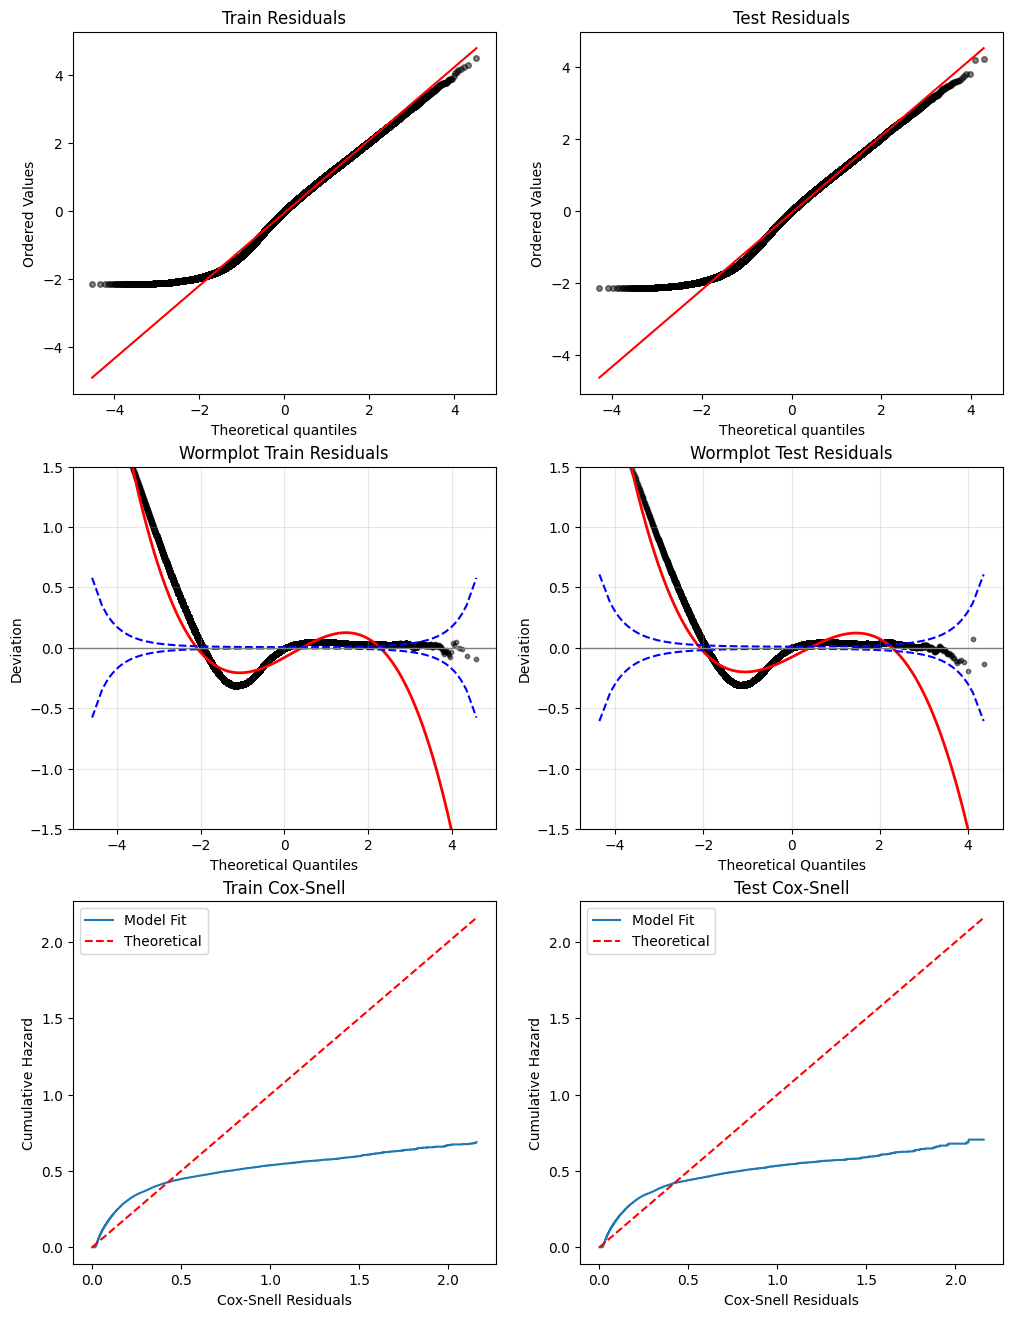

In [29]:
quant_residuals_train = utils.compute_randomized_residuals_censoring(S_train, delta_train)
quant_residuals_test = utils.compute_randomized_residuals_censoring(S_test, delta_test)
cs_residuals_train = H_train
cs_residuals_test = H_test 

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

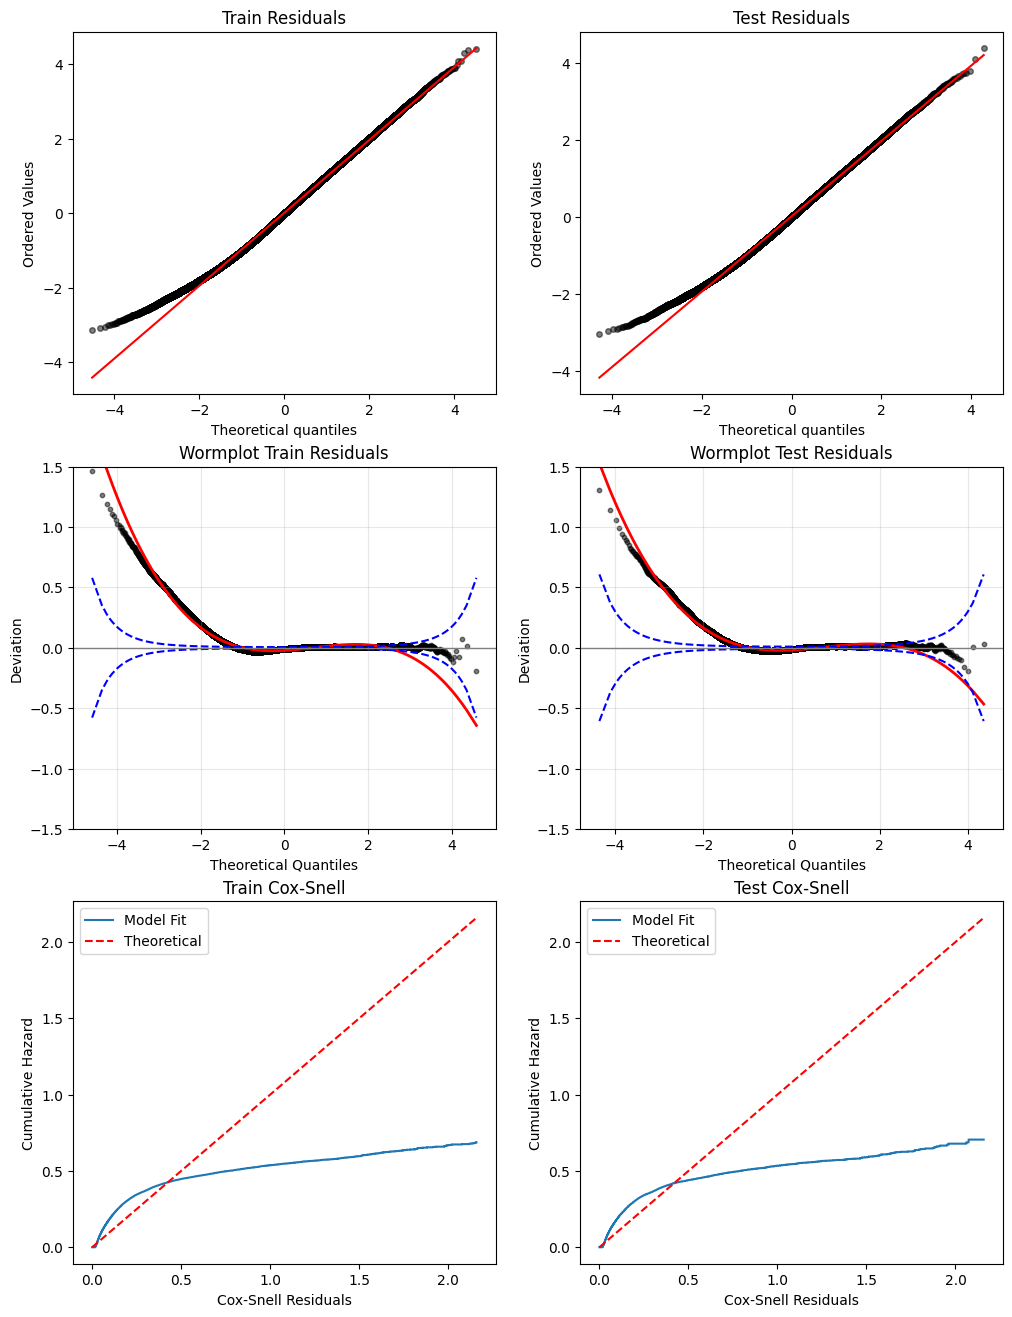

In [30]:
quant_residuals_train_full = utils.compute_randomized_residuals_censoring(S_train_full, delta_train)
quant_residuals_test_full = utils.compute_randomized_residuals_censoring(S_test_full, delta_test)
cs_residuals_train_full = H_train_full
cs_residuals_test_full = H_test_full

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_full, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_full, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_full, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_full, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

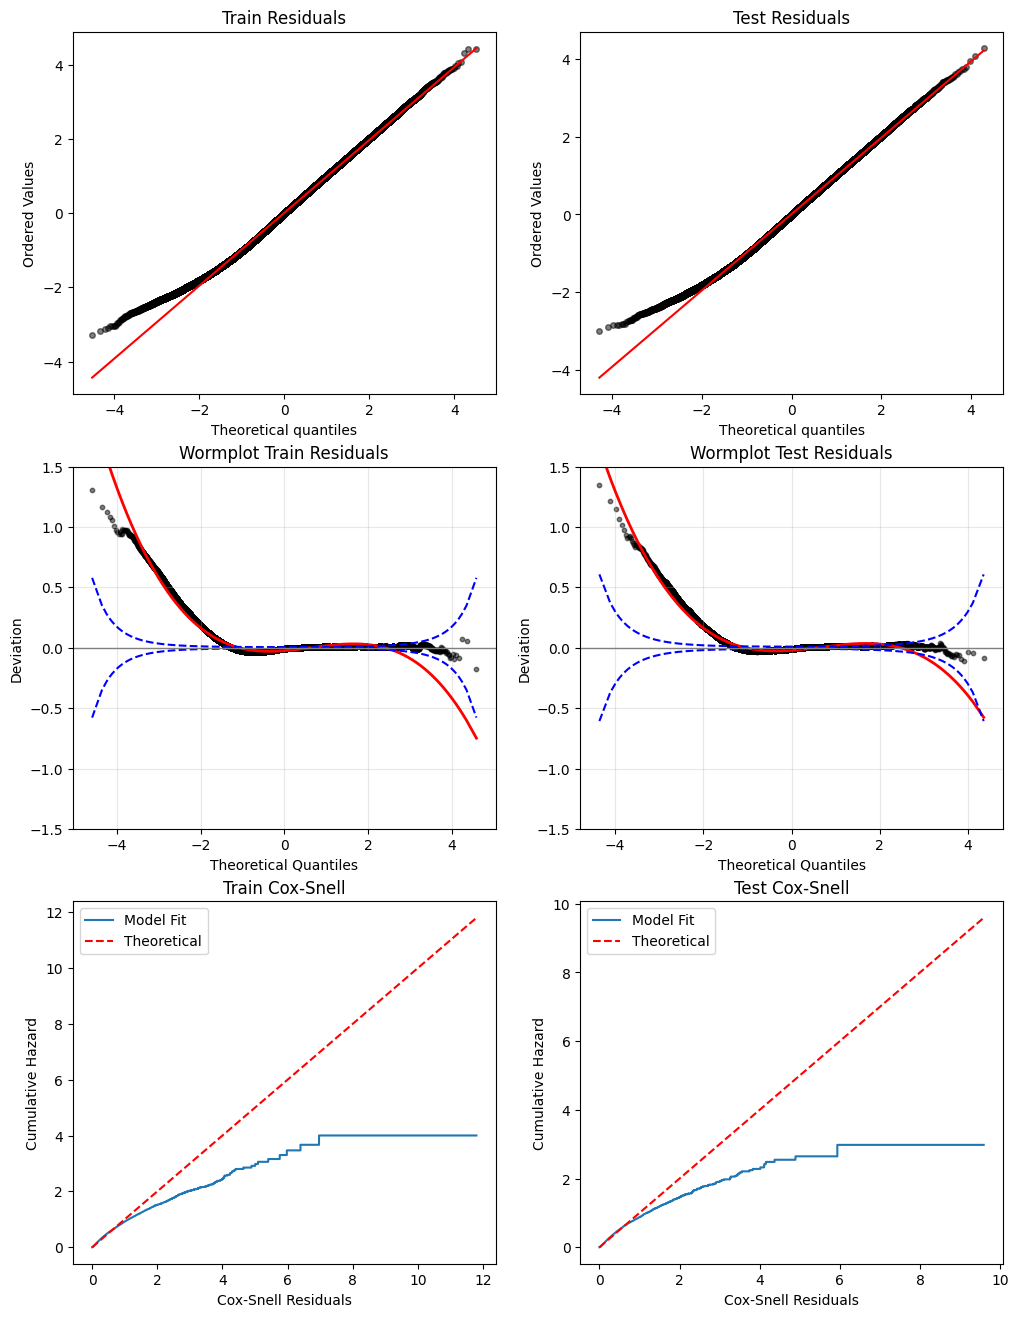

In [31]:
quant_residuals_train_linear = utils.compute_randomized_residuals_censoring(S_train_linear, delta_train)
quant_residuals_test_linear = utils.compute_randomized_residuals_censoring(S_test_linear, delta_test)
cs_residuals_train_linear = H_train_linear
cs_residuals_test_linear = H_test_linear

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_qq(quant_residuals_train_linear, ax = ax[0,0], title = "Train Residuals")
utils.plot_qq(quant_residuals_test_linear, ax = ax[0,1], title = "Test Residuals")
utils.plot_worm(quant_residuals_train_linear, ax = ax[1,0], title = "Wormplot Train Residuals")
utils.plot_worm(quant_residuals_test_linear, ax = ax[1,1], title = "Wormplot Test Residuals")
utils.plot_cox_snell(cs_residuals_train_linear, delta_train, ax = ax[2,0], title = "Train Cox-Snell")
utils.plot_cox_snell(cs_residuals_test_linear, delta_test, ax = ax[2,1], title = "Test Cox-Snell")

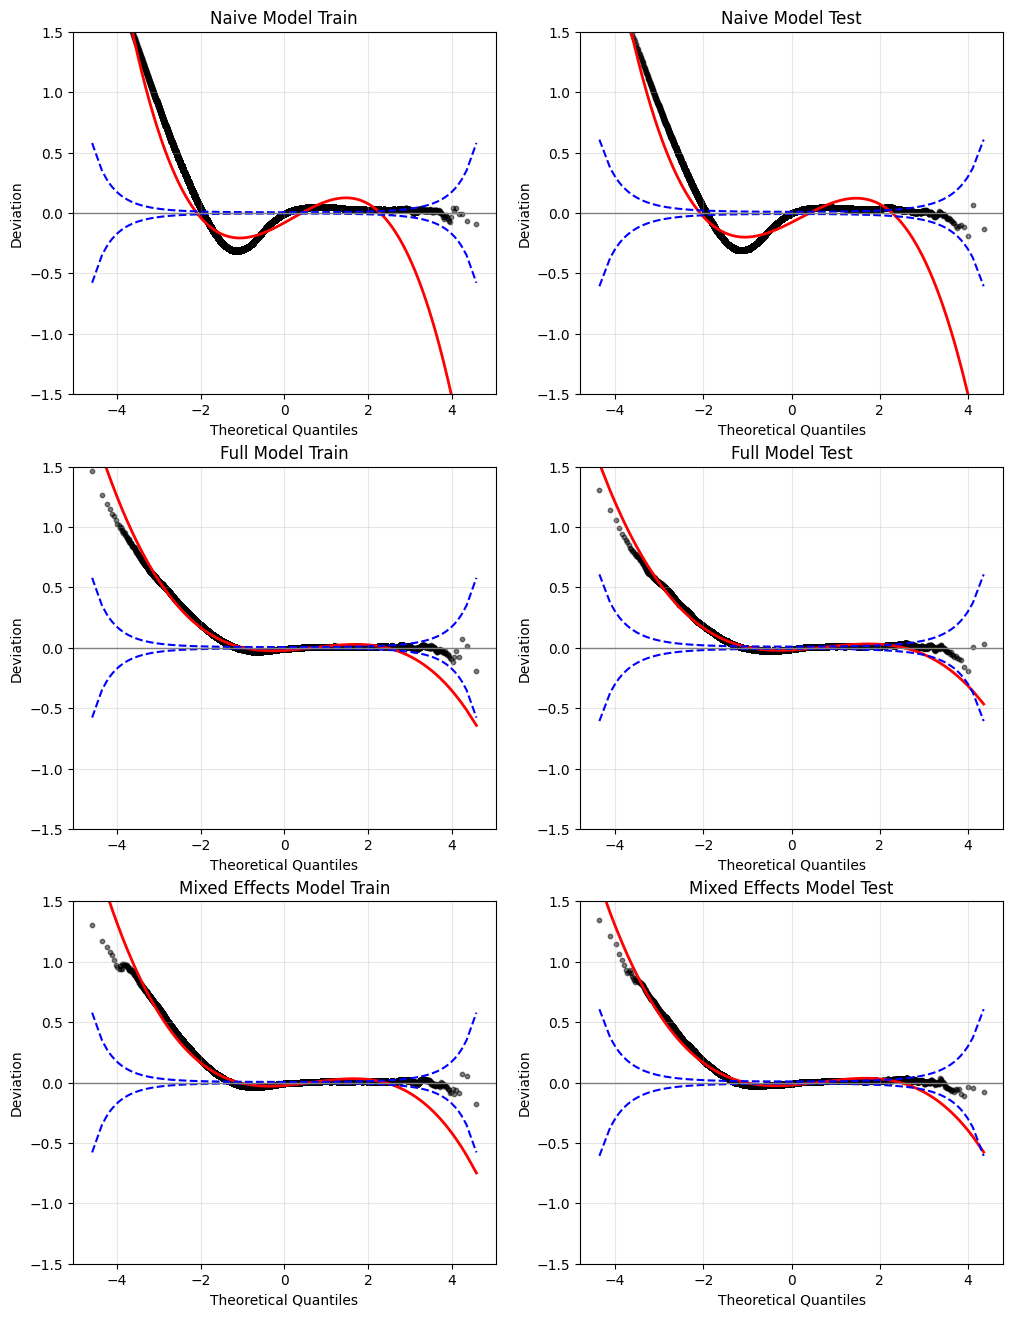

In [32]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (12,16))

utils.plot_worm(quant_residuals_train, ax = ax[0,0], title = "Naive Model Train")
utils.plot_worm(quant_residuals_test, ax = ax[0,1], title = "Naive Model Test")
utils.plot_worm(quant_residuals_train_full, ax = ax[1,0], title = "Full Model Train")
utils.plot_worm(quant_residuals_test_full, ax = ax[1,1], title = "Full Model Test")
utils.plot_worm(quant_residuals_train_linear, ax = ax[2,0], title = "Mixed Effects Model Train")
utils.plot_worm(quant_residuals_test_linear, ax = ax[2,1], title = "Mixed Effects Model Test")